## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.funcionesModeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   MarketCap_log               18028 non-null  float64       
 1   Close_log                   18028 non-null  float64       
 2   TrailingPE                  18028 non-null  float64       
 3   EnterpriseToEbitda          18028 non-null  float64       
 4   PriceToBook                 18028 non-null  float64       
 5   EnterpriseValue             18028 non-null  float64       
 6   TotalAssets                 18028 non-null  float64       
 7   TotalRevenue                18028 non-null  float64       
 8   TotalEquity                 18028 non-null  float64       
 9   BasicAvgShares              18028 non-null  float64       
 10  Date                        18028 non-null  datetime64[ns]
 11  Ticker                      18028 non-null  object    

## Feature Engineering

Sección para crear variables en la fase de modelado. 
La mayor parte de las variables fue creada en la fase de extracción.

In [3]:
# Calcular las aceleraciones netas (Momento - Tendencia) para variables de crecimiento.
# Una vez calculadas, se eliminan las variables trimestrales (reemplazar=True)
variables_de_crecimiento = ['Revenue_QoQ', 'EBITDA_QoQ', 'FCF_QoQ', 'Capex_QoQ']
df = calcular_acceleration_features(df, variables_de_crecimiento, reemplazar= True)

In [4]:
# Sectores poco significativos: se agrupan en la categoria "Other"
# Se saltea en la versión actual
#sectores_importantes = ['InformationTechnology', 'Energy']

#df['Sector'] = np.where(df['Sector'].isin(sectores_importantes), df['Sector'], 'Other')

# Se vuelve a convertir en category
#df['Sector'] = df['Sector'].astype('category')

# Modelo de ensamblado de árboles RandomForest

In [4]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores:
predictores_a_eliminar = [
    # Ticker y fecha
    'Ticker',
    'Date',
    # Variables que dependen del precio
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda', 
    'Close_log',
    'MarketCap_log',
    'EnterpriseValue',
    # Variables originales del Balance
    'TotalEquity',
    'TotalAssets',
    'TotalRevenue',
    'BasicAvgShares',  
    # Variables con baja relevancia
    'MonthlyReturn', 
    'MarketCovariance'
    ]

# Se define la variable objetivo y las variables predictoras
label = 'MarketCap_log'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = ['Sector']

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        max_features='sqrt',
        max_samples= 0.8,
        min_samples_split= 10         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.9180


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.7914 ± 0.0288


In [6]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(20)

,feature,importance
15,num__RelativeRevenue_log,0.178874
14,num__RelativeAssets_log,0.165350
16,num__RelativeEquity_log,0.142202
3,num__ReturnOnAssets,0.057270
11,num__YearsSinceAdded,0.052617
2,num__ProfitMargins,0.045127
1,num__OperatingMargins,0.044532
8,num__NetDebt_to_EBITDA,0.038182
18,num__Revenue_Acceleration,0.035791
4,num__Revenue_YoY,0.031200


In [7]:
feature_importance_df.tail(20)

,feature,importance
10,num__Capex_to_Revenue,0.017828
17,num__CurrentRatio_log,0.017451
0,num__MonthlyVariance,0.013488
5,num__EBITDA_YoY,0.011125
19,num__EBITDA_Acceleration,0.010702
6,num__FCF_YoY,0.009199
20,num__FCF_Acceleration,0.009121
21,num__Capex_Acceleration,0.008116
7,num__Capex_YoY,0.008008
22,cat__Sector_CommunicationServices,0.006824


## Aplicacion del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [9]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 167 tickers, residuo medio global: 0.2760
Underprediction: 288 tickers, residuo medio global: -0.3733


In [10]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Revertir la transformación log1p a precios lineales para el reporte
resultados_agrupados['PredictedValue'] = np.expm1(resultados_agrupados['Predicted'])
resultados_agrupados['ObservedValue'] = np.expm1(resultados_agrupados['Observed'])

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['PredictedValue'] - resultados_agrupados['ObservedValue'])/ resultados_agrupados['ObservedValue'])*100

resultados_agrupados.drop(columns=['Predicted', 'Observed', 'Residuals'], inplace=True)

print(resultados_agrupados.head().to_string(index=False))

Ticker      Cluster  PredictedValue  ObservedValue  PercentError
   MOS PositiveBias       19.264828       6.884594    179.825199
   TTD PositiveBias       22.892601       9.257750    147.280385
    CF PositiveBias       40.108256      17.116138    134.330055
   CAG PositiveBias       14.876508       6.485748    129.372277
  PSKY PositiveBias       15.381045       6.839200    124.895375


In [11]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Cluster,PredictedValue,ObservedValue,PercentError,MarketCap_log,Close_log,TrailingPE,EnterpriseToEbitda,PriceToBook,...,ReturnOnEquity_Transformed,DebtToEquity_Transformed,RelativeAssets_log,RelativeRevenue_log,RelativeEquity_log,CurrentRatio_log,Revenue_Acceleration,EBITDA_Acceleration,FCF_Acceleration,Capex_Acceleration
0,MOS,PositiveBias,19.264828,6.884594,179.825199,2.064911,3.121924,12.7327,4.7468,0.5697,...,-0.081611,-0.069628,0.000961,0.000742,0.001327,0.839410,-0.083557,-0.594143,2.464774,0.085883
1,TTD,PositiveBias,22.892601,9.257750,147.280385,2.328034,2.993730,20.8835,12.8150,3.7264,...,-0.014563,-0.092513,0.000242,0.000178,0.000273,0.959657,-0.184637,-0.370010,-0.237974,0.959194
2,CF,PositiveBias,40.108256,17.116138,134.330055,2.896803,4.668990,11.7637,5.7191,3.5379,...,0.046330,-0.041938,0.000553,0.000436,0.000532,1.473687,-0.193377,-0.161321,-0.029031,0.825263
3,CAG,PositiveBias,14.876508,6.485748,129.372277,2.013001,2.678278,5.6280,7.3694,0.7261,...,-0.039275,-0.028557,0.000822,0.000715,0.000981,0.537312,0.036354,-0.358115,0.199631,0.003092
4,PSKY,PositiveBias,15.381045,6.839200,124.895375,2.059137,2.424803,-1.1049,-4.0055,0.4191,...,-0.297816,-0.024174,0.001812,0.001797,0.001792,0.833909,0.000000,0.000000,0.000000,0.000000


## Explicabilidad del Modelo (SHAP)

In [12]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'MOS'

--- Explicación de la predicción (en precios lineales USD) para: MOS ---


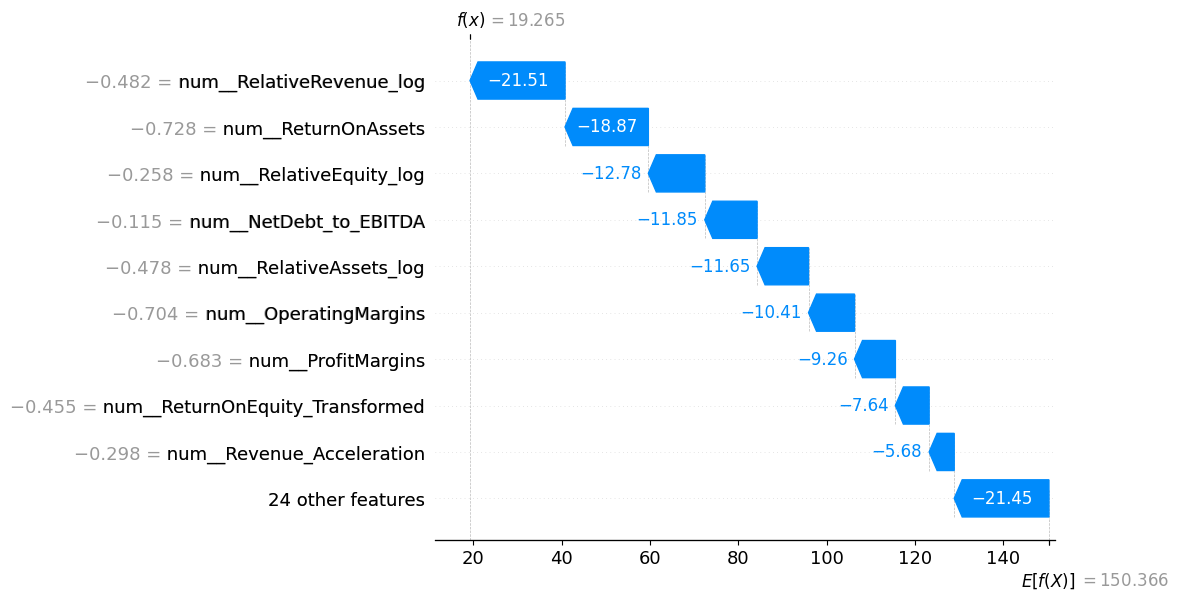

In [13]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Definir la función del modelo en escala lineal (dólares en lugar de log)
def modelo_lineal(X_dataframe):
    # Se extrae el array de NumPy puro para evitar warnings
    X_array = X_dataframe.values if hasattr(X_dataframe, 'values') else X_dataframe
    
    # El modelo predice en logaritmo (Close_log)
    predicciones_log = rf_model.predict(X_array)
    
    # Revertimos el logaritmo a escala lineal
    return np.expm1(predicciones_log)


# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    # Usamos una muestra de 100 datos como "fondo" para calcular el Valor Base promedio en dólares
    datos_referencia = shap.sample(X_test_shap, 100)
    explainer = shap.Explainer(modelo_lineal, datos_referencia)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción (en precios lineales USD) para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    # Pasamos shap_values[0] porque ahora solo evaluamos 1 fila
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiperparámetros

In [13]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [10],
        'rf__min_samples_leaf': [10],
        'rf__min_samples_split': [10],
        'rf__max_samples': [0.8],
        'rf__max_features': ['sqrt']
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)